## Phase 5: Statistical Analysis - Your Step-by-Step Guide

Welcome to Phase 5! Here, we'll dive into the numbers to see what they really tell us about customer churn. Think of this as putting on your detective hat and looking for clues in the data.

### What We Want to Find Out (Our Objectives):

By the end of this section, we'll aim to answer some key questions:

1.  **Contract Type & Churn**: Is there a real connection between the type of contract a customer has (e.g., month-to-month, one-year) and whether they churn? Or is it just a coincidence?
2.  **Monthly Charges & Churn**: Do customers who churn tend to pay significantly more (or less) each month compared to those who stay?
3.  **Tenure & Churn**: Is there a noticeable difference in how long churned customers have been with us versus those who remain loyal?
4.  **Gender & Churn**: Does a customer's gender seem to play a role in their likelihood of churning?
5.  **Strongest Influencers**: Which of all the factors we're looking at has the most significant statistical relationship with churn?

### How We'll Do It (Our Workflow):

We'll follow a clear process, step-by-step, to make sure our findings are sound:

1.  **Review EDA Insights**: First, we'll remind ourselves of what we've already learned from our initial data exploration (EDA). This helps us form smart questions.
2.  **Form Hypotheses**: Based on those insights, we'll create specific, testable statements about what we *think* might be true (e.g., "Customers with month-to-month contracts are more likely to churn.").
3.  **Choose the Right Test**: We'll pick the best statistical tool for each question. For example, some questions need a t-test, others a chi-square test.
4.  **Perform the Test**: We'll run the chosen statistical tests using our data.
5.  **Interpret the p-value**: This is a crucial step! The p-value tells us how likely our observed results are if there's *no real effect*. A small p-value usually suggests a real effect.
6.  **Business Interpretation**: We'll translate the statistical results into plain English that makes sense for our business decisions. What does it *mean* for us?
7.  **Report Findings**: Finally, we'll summarize all our discoveries, highlighting what's important and how it can help us understand and reduce churn.

In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import pearsonr

import scipy.stats as stats

In [ ]:
df = pd.read_csv("Customer_Churn_Cleaned.csv")

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7016,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7017,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7018,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7019,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [ ]:
df = pd.read_csv("Customer_Churn_Cleaned.csv")

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7016,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7017,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7018,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7019,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


# **Chi-Square Test**
Example: Contract Type vs Churn
Hypotheses

H₀ (Null Hypothesis):

Contract type and churn are independent.

H₁ (Alternative Hypothesis):

Contract type and churn are associated.

In [ ]:
contingency_table = pd.crosstab(df["Contract"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-value :", p)

Chi-Square Statistic : 1179.8029713383091
P-value : 6.442284610021268e-257


In [ ]:
alpha = 0.05

if p < alpha:
    print("Reject H0")
    print("Contract Type significantly affects churn.")
else:
    print("Fail to Reject H0")

Reject H0
Contract Type significantly affects churn.


In [ ]:
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [ ]:
for col in categorical_columns:

    table = pd.crosstab(df[col], df["Churn"])

    chi2, p, dof, exp = chi2_contingency(table)

    print("="*50)
    print(col)
    print("P-value:", p)

    if p < 0.05:
        print("Significant")
    else:
        print("Not Significant")

gender
P-value: 0.4794615390898278
Not Significant
Partner
P-value: 1.0999615978939857e-35
Significant
Dependents
P-value: 1.5995676694072134e-42
Significant
PhoneService
P-value: 0.3664940064978197
Not Significant
MultipleLines
P-value: 0.0020685599531309134
Significant
InternetService
P-value: 1.0857790034735195e-159
Significant
OnlineSecurity
P-value: 1.329226523787891e-184
Significant
OnlineBackup
P-value: 8.614898409283198e-131
Significant
DeviceProtection
P-value: 1.9555513236078665e-121
Significant
TechSupport
P-value: 7.146857715828324e-180
Significant
StreamingTV
P-value: 5.469454144000632e-82
Significant
StreamingMovies
P-value: 2.750289622934079e-82
Significant
Contract
P-value: 6.442284610021268e-257
Significant
PaperlessBilling
P-value: 2.1518977990247168e-57
Significant
PaymentMethod
P-value: 3.0267752570875056e-139
Significant


#Independent Sample t-test

Example 1: Monthly Charges
Hypotheses

H₀

Mean Monthly Charges are equal for churned and retained customers.

H₁

The means are different.

In [ ]:
churn_yes = df[df["Churn"]==1]["MonthlyCharges"]

churn_no = df[df["Churn"]==0]["MonthlyCharges"]

t_stat, p = ttest_ind(
    churn_yes,
    churn_no,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P-value:", p)

T Statistic: 18.51706802600587
P-value: 1.372804552506739e-73


In [ ]:
if p < 0.05:
    print("Monthly Charges differ significantly.")
else:
    print("No significant difference.")

Monthly Charges differ significantly.


In [ ]:
#Tenure
churn_yes = df[df["Churn"]==1]["tenure"]

churn_no = df[df["Churn"]==0]["tenure"]

t_stat, p = ttest_ind(
    churn_yes,
    churn_no,
    equal_var=False
)

print(t_stat)
print(p)

-34.66878347699738
1.4676429262286135e-230


In [ ]:
#Total Charges
churn_yes = df[df["Churn"]==1]["TotalCharges"]

churn_no = df[df["Churn"]==0]["TotalCharges"]

t_stat, p = ttest_ind(
    churn_yes,
    churn_no,
    equal_var=False
)

print(t_stat)
print(p)

-18.623375140683542
2.6647006477771723e-74


**Correlation Analysis**

In [ ]:
numeric_df = df.select_dtypes(include=["int64","float64"])

In [ ]:
corr = numeric_df.corr()

print(corr)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen        1.000000  0.015349        0.219434      0.101884   
tenure               0.015349  1.000000        0.245251      0.824871   
MonthlyCharges       0.219434  0.245251        1.000000      0.650339   
TotalCharges         0.101884  0.824871        0.650339      1.000000   
Churn                0.151619 -0.351508        0.194508     -0.197914   

                   Churn  
SeniorCitizen   0.151619  
tenure         -0.351508  
MonthlyCharges  0.194508  
TotalCharges   -0.197914  
Churn           1.000000  


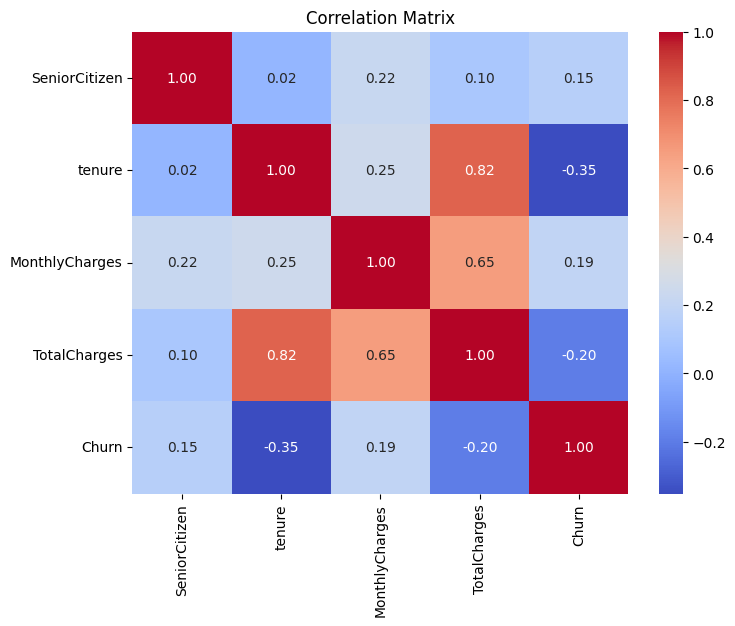

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
#Pearson Correlation

corr, p = pearsonr(
    df["MonthlyCharges"],
    df["TotalCharges"]
)

print(corr)
print(p)

0.6503387018445006
0.0


**Interpretation:**

Correlation coefficient indicates the strength and direction of the linear relationship.
The p-value tells us whether the correlation is statistically significant.

In [ ]:
#Confidence Interval

mean = df["MonthlyCharges"].mean()

std = df["MonthlyCharges"].std()

n = len(df)

margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin

upper = mean + margin

print(lower, upper)

64.1485376900981 65.55525094399962


In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("Customer_Churn_Cleaned.csv")

# =====================================================
# Significance Level
# =====================================================

alpha = 0.05

# =====================================================
# Store Results
# =====================================================

results = []

# =====================================================
# Business Interpretation Dictionary
# =====================================================

business_dict = {

    "gender":
    "Gender has no practical influence on customer retention strategies.",

    "SeniorCitizen":
    "Senior citizens may require targeted retention strategies.",

    "Partner":
    "Customers with partners may exhibit different loyalty patterns.",

    "Dependents":
    "Customers with dependents may have different retention behaviour.",

    "PhoneService":
    "Phone service subscription may influence customer retention.",

    "MultipleLines":
    "Multiple line subscriptions may impact churn behaviour.",

    "InternetService":
    "Internet service type strongly affects customer churn.",

    "OnlineSecurity":
    "Customers without online security are more likely to churn.",

    "OnlineBackup":
    "Online backup service may improve customer retention.",

    "DeviceProtection":
    "Customers with device protection tend to stay longer.",

    "TechSupport":
    "Technical support significantly improves customer retention.",

    "StreamingTV":
    "Streaming TV subscription may influence churn.",

    "StreamingMovies":
    "Streaming movie subscription may influence churn.",

    "Contract":
    "Contract type plays an important role in customer loyalty.",

    "PaperlessBilling":
    "Billing method may influence customer churn.",

    "PaymentMethod":
    "Certain payment methods exhibit higher churn rates.",

    "MonthlyCharges":
    "Monthly charges significantly affect customer churn.",

    "tenure":
    "Customer tenure strongly influences retention.",

    "TotalCharges":
    "Lifetime spending differs between churned and retained customers."
}

# =====================================================
# Categorical Variables (Chi-Square Test)
# =====================================================

categorical_columns = [

    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"

]

for col in categorical_columns:

    contingency = pd.crosstab(df[col], df["Churn"])

    chi2, p, dof, expected = chi2_contingency(contingency)

    decision = "Reject H₀" if p < alpha else "Fail to Reject H₀"

    significance = "Significant" if p < alpha else "Not Significant"

    interpretation = (
        business_dict[col]
        if p < alpha
        else f"No statistically significant relationship between {col} and customer churn."
    )

    results.append({

        "Variable": col,
        "Test": "Chi-Square",
        "Statistic": round(chi2,3),
        "P-value": round(p,6),
        "Decision": decision,
        "Conclusion": significance,
        "Business Interpretation": interpretation

    })

# =====================================================
# Numerical Variables (Independent T-Test)
# =====================================================

numerical_columns = [

    "MonthlyCharges",
    "tenure",
    "TotalCharges"

]

for col in numerical_columns:

    churn_yes = df[df["Churn"] == 1][col]

    churn_no = df[df["Churn"] == 0][col]

    t_stat, p = ttest_ind(
        churn_yes,
        churn_no,
        equal_var=False
    )

    decision = "Reject H₀" if p < alpha else "Fail to Reject H₀"

    significance = "Significant" if p < alpha else "Not Significant"

    interpretation = (
        business_dict[col]
        if p < alpha
        else f"No statistically significant difference in {col} between churned and retained customers."
    )

    results.append({

        "Variable": col,
        "Test": "Independent T-Test",
        "Statistic": round(t_stat,3),
        "P-value": round(p,6),
        "Decision": decision,
        "Conclusion": significance,
        "Business Interpretation": interpretation

    })

# =====================================================
# Final Summary Table
# =====================================================

summary = pd.DataFrame(results)

summary = summary.sort_values(
    by="P-value"
)

summary.reset_index(
    drop=True,
    inplace=True
)

print(summary)

# =====================================================
# Save Results
# =====================================================

summary.to_csv(
    "Statistical_Test_Summary.csv",
    index=False
)

print("\nStatistical summary saved successfully!")

            Variable                Test  Statistic   P-value  \
0      SeniorCitizen          Chi-Square    160.470  0.000000   
1            Partner          Chi-Square    155.480  0.000000   
2         Dependents          Chi-Square    186.786  0.000000   
3     OnlineSecurity          Chi-Square    846.782  0.000000   
4    InternetService          Chi-Square    732.057  0.000000   
5        TechSupport          Chi-Square    824.997  0.000000   
6   DeviceProtection          Chi-Square    555.884  0.000000   
7       OnlineBackup          Chi-Square    598.970  0.000000   
8    StreamingMovies          Chi-Square    375.601  0.000000   
9           Contract          Chi-Square   1179.803  0.000000   
10  PaperlessBilling          Chi-Square    254.962  0.000000   
11       StreamingTV          Chi-Square    374.226  0.000000   
12     PaymentMethod          Chi-Square    643.923  0.000000   
13      TotalCharges  Independent T-Test    -18.623  0.000000   
14            tenure  Ind

In [ ]:
#Assumption Checking (Normality & Equal Variance)

# =====================================================
# ASSUMPTION CHECKING FOR T-TESTS
# =====================================================

from scipy.stats import shapiro, levene

numerical_columns = ["MonthlyCharges", "tenure", "TotalCharges"]

print("="*80)
print("ASSUMPTION CHECKING")
print("="*80)

for col in numerical_columns:

    churn_yes = df[df["Churn"] == 1][col]
    churn_no = df[df["Churn"] == 0][col]

    print("\n" + "="*60)
    print(f"Variable : {col}")
    print("="*60)

    # ----------------------------
    # Shapiro-Wilk Normality Test
    # ----------------------------

    stat_yes, p_yes = shapiro(churn_yes.sample(min(500, len(churn_yes)), random_state=42))
    stat_no, p_no = shapiro(churn_no.sample(min(500, len(churn_no)), random_state=42))

    print("\nShapiro-Wilk Test")

    print(f"Churn = Yes : p-value = {p_yes:.5f}")
    print(f"Churn = No  : p-value = {p_no:.5f}")

    if p_yes > 0.05 and p_no > 0.05:
        print("Conclusion : Both groups appear approximately normal.")
    else:
        print("Conclusion : At least one group deviates from normality.")

    # ----------------------------
    # Levene's Test
    # ----------------------------

    stat, p = levene(churn_yes, churn_no)

    print("\nLevene's Test")

    print(f"P-value = {p:.5f}")

    if p > 0.05:
        print("Conclusion : Equal variances assumed.")
    else:
        print("Conclusion : Variances are unequal.")

    print("\nDecision : Welch's T-Test (equal_var=False) is appropriate when variances are unequal.")

ASSUMPTION CHECKING

Variable : MonthlyCharges

Shapiro-Wilk Test
Churn = Yes : p-value = 0.00000
Churn = No  : p-value = 0.00000
Conclusion : At least one group deviates from normality.

Levene's Test
P-value = 0.00000
Conclusion : Variances are unequal.

Decision : Welch's T-Test (equal_var=False) is appropriate when variances are unequal.

Variable : tenure

Shapiro-Wilk Test
Churn = Yes : p-value = 0.00000
Churn = No  : p-value = 0.00000
Conclusion : At least one group deviates from normality.

Levene's Test
P-value = 0.00000
Conclusion : Variances are unequal.

Decision : Welch's T-Test (equal_var=False) is appropriate when variances are unequal.

Variable : TotalCharges

Shapiro-Wilk Test
Churn = Yes : p-value = 0.00000
Churn = No  : p-value = 0.00000
Conclusion : At least one group deviates from normality.

Levene's Test
P-value = 0.00000
Conclusion : Variances are unequal.

Decision : Welch's T-Test (equal_var=False) is appropriate when variances are unequal.


In [ ]:
#Effect Size (Cohen's d)

# =====================================================
# COHEN'S D EFFECT SIZE
# =====================================================

def cohens_d(group1, group2):

    n1 = len(group1)
    n2 = len(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) /
        (n1 + n2 - 2)
    )

    d = (group1.mean() - group2.mean()) / pooled_std

    return d


effect_results = []

print("="*80)
print("COHEN'S D EFFECT SIZE")
print("="*80)

for col in numerical_columns:

    churn_yes = df[df["Churn"] == 1][col]
    churn_no = df[df["Churn"] == 0][col]

    d = cohens_d(churn_yes, churn_no)

    abs_d = abs(d)

    if abs_d < 0.20:
        magnitude = "Negligible"

    elif abs_d < 0.50:
        magnitude = "Small"

    elif abs_d < 0.80:
        magnitude = "Medium"

    else:
        magnitude = "Large"

    effect_results.append({

        "Variable": col,
        "Cohen_d": round(d,3),
        "Magnitude": magnitude

    })

effect_df = pd.DataFrame(effect_results)

print(effect_df)

effect_df.to_csv("Effect_Size_Summary.csv", index=False)

print("\nEffect Size Summary saved successfully.")

COHEN'S D EFFECT SIZE
         Variable  Cohen_d Magnitude
0  MonthlyCharges    0.450     Small
1          tenure   -0.851     Large
2    TotalCharges   -0.458     Small

Effect Size Summary saved successfully.


In [ ]:
#Combined Statistical Report

# =====================================================
# FINAL STATISTICAL FINDINGS
# =====================================================

print("\n")
print("="*90)
print("FINAL STATISTICAL FINDINGS")
print("="*90)

# Significant categorical variables
significant_cat = summary[
    (summary["Test"] == "Chi-Square") &
    (summary["Decision"] == "Reject H₀")
]["Variable"].tolist()

# Significant numerical variables
significant_num = summary[
    (summary["Test"] == "Independent T-Test") &
    (summary["Decision"] == "Reject H₀")
]["Variable"].tolist()

print("\nSignificant Categorical Variables")

for var in significant_cat:
    print(f"• {var}")

print("\nSignificant Numerical Variables")

for var in significant_num:
    print(f"• {var}")

print("\nEffect Sizes")

print(effect_df)

print("\nOverall Conclusion")

print("-"*80)

if "Contract" in significant_cat:
    print("• Contract type significantly influences customer churn.")

if "OnlineSecurity" in significant_cat:
    print("• Customers without online security exhibit significantly higher churn.")

if "TechSupport" in significant_cat:
    print("• Technical support is associated with improved customer retention.")

if "PaymentMethod" in significant_cat:
    print("• Customer payment method is significantly associated with churn.")

if "tenure" in significant_num:
    print("• Churned customers have significantly different tenure than retained customers.")

if "MonthlyCharges" in significant_num:
    print("• Monthly charges differ significantly between churned and retained customers.")

if "TotalCharges" in significant_num:
    print("• Total charges differ significantly between churned and retained customers.")

print("\nStatistical analysis completed successfully.")



FINAL STATISTICAL FINDINGS

Significant Categorical Variables
• SeniorCitizen
• Partner
• Dependents
• OnlineSecurity
• InternetService
• TechSupport
• DeviceProtection
• OnlineBackup
• StreamingMovies
• Contract
• PaperlessBilling
• StreamingTV
• PaymentMethod
• MultipleLines

Significant Numerical Variables
• TotalCharges
• tenure
• MonthlyCharges

Effect Sizes
         Variable  Cohen_d Magnitude
0  MonthlyCharges    0.450     Small
1          tenure   -0.851     Large
2    TotalCharges   -0.458     Small

Overall Conclusion
--------------------------------------------------------------------------------
• Contract type significantly influences customer churn.
• Customers without online security exhibit significantly higher churn.
• Technical support is associated with improved customer retention.
• Customer payment method is significantly associated with churn.
• Churned customers have significantly different tenure than retained customers.
• Monthly charges differ significantly 

In [ ]:
#Export Complete Statistical Summary

# =====================================================
# MERGE P-VALUE SUMMARY + EFFECT SIZE
# =====================================================

final_summary = summary.merge(
    effect_df,
    on="Variable",
    how="left"
)

final_summary.to_excel(
    "Final_Statistical_Analysis_Report.xlsx",
    index=False
)

print("Final statistical report exported successfully.")

Final statistical report exported successfully.
